In [40]:
import pandas as pd

In [41]:
df = pd.read_csv('/content/New_Data_Generate.csv')

In [42]:
df.head()

,Customer_Id,Genre,Age,Annual Income (k$),Spending_Score (1-30)
0,1,Male,19,15,12
1,2,Male,21,15,24
2,3,Female,20,16,2
3,4,Female,23,16,23
4,5,Female,31,17,12


In [43]:
df.tail()

,Customer_Id,Genre,Age,Annual Income (k$),Spending_Score (1-30)
35,36,Female,21,33,24
36,37,Female,42,34,5
37,38,Female,30,34,22
38,39,Female,36,37,8
39,40,Female,20,37,22


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Customer_Id            40 non-null     int64 
 1   Genre                  40 non-null     object
 2   Age                    40 non-null     int64 
 3   Annual Income (k$)     40 non-null     int64 
 4   Spending_Score (1-30)  40 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.7+ KB


In [45]:
df.isnull().sum()

,0
Customer_Id,0
Genre,0
Age,0
Annual Income (k$),0
Spending_Score (1-30),0


In [46]:
df.describe()

,Customer_Id,Age,Annual Income (k$),Spending_Score (1-30)
count,40.000000,40.000000,40.000000,40.00000
mean,20.500000,34.650000,24.450000,14.70000
std,11.690452,13.775768,6.574816,9.58685
min,1.000000,18.000000,15.000000,1.00000
25%,10.750000,22.750000,19.000000,5.00000
50%,20.500000,33.000000,23.500000,15.00000
75%,30.250000,42.750000,29.250000,23.00000
max,40.000000,67.000000,37.000000,29.00000


IMPORT K-MEANS LIBRARY

In [47]:
from sklearn.cluster import KMeans

SELECT FEATURE

In [48]:
df.columns

Index(['Customer_Id', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending_Score (1-30)'],
      dtype='object')

In [49]:
X = df[['Annual Income (k$)','Spending_Score (1-30)']]

In [50]:
X

,Annual Income (k$),Spending_Score (1-30)
0,15,12
1,15,24
2,16,2
3,16,23
4,17,12
5,17,22
6,18,2
7,18,28
8,19,1
9,19,21


Fit to k_means

In [51]:
k_means = KMeans()
k_means.fit(X)

KMeans()

Predict Cluster

In [52]:
k_means = KMeans(n_clusters=5)
k_means.fit_predict(X)

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 1, 2, 1, 2, 1, 2,
       3, 2, 3, 0, 1, 0, 1, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0], dtype=int32)

Find Optimal Numbers Of Cluster Using Elbow Methods

In [53]:
wcss = []
for i in range(1,11):
  k_means = KMeans(n_clusters=i)
  k_means.fit(X)
  wcss.append(k_means.inertia_)

In [54]:
wcss

[5270.300000000002,
 2137.3999999999996,
 1467.0717171717174,
 809.7373737373738,
 631.7516594516595,
 559.095238095238,
 502.8904761904762,
 397.6531746031746,
 311.1547619047619,
 236.60714285714286]

Import Matplotlib Library

In [55]:
import matplotlib.pyplot as plt

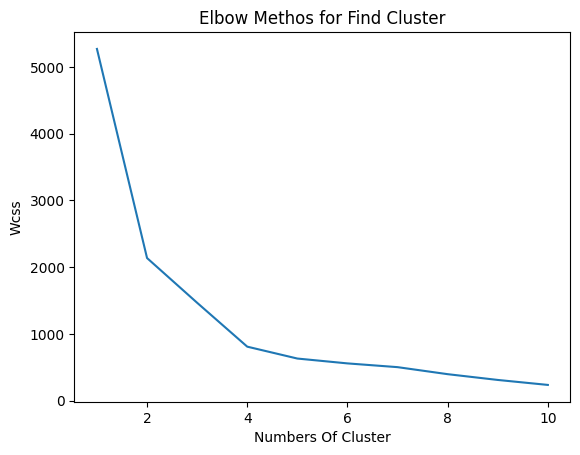

In [56]:
plt.plot(range(1,11),wcss)
plt.title('Elbow Methos for Find Cluster')
plt.xlabel('Numbers Of Cluster')
plt.ylabel('Wcss')
plt.show()

Model Training

In [57]:
X = df[['Annual Income (k$)','Spending_Score (1-30)']]

In [58]:
k_means = KMeans(n_clusters=4,random_state=42)
y_means = k_means.fit_predict(X)

In [59]:
y_means

array([0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1], dtype=int32)

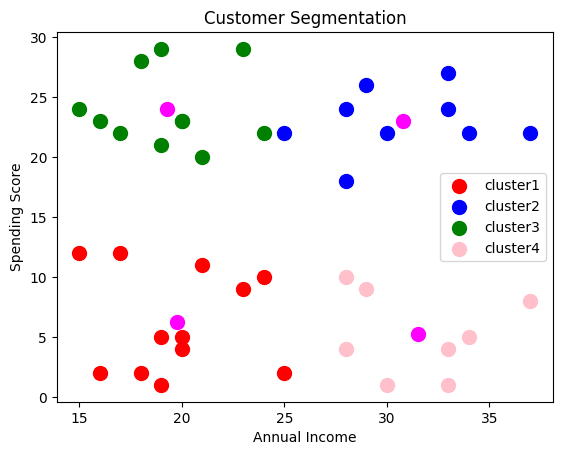

In [60]:
plt.scatter(X.iloc[y_means==0,0],X.iloc[y_means==0,1],s=100,c='red',label='cluster1')
plt.scatter(X.iloc[y_means==1,0],X.iloc[y_means==1,1],s=100,c='blue',label='cluster2')
plt.scatter(X.iloc[y_means==2,0],X.iloc[y_means==2,1],s=100,c='green',label='cluster3')
plt.scatter(X.iloc[y_means==3,0],X.iloc[y_means==3,1],s=100,c='pink',label='cluster4')
plt.scatter(k_means.cluster_centers_[:,0],k_means.cluster_centers_[:,1],s=100,c='magenta')
plt.title('Customer Segmentation')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [62]:
k_means.predict([[15,39]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([2], dtype=int32)

In [64]:
import joblib

In [65]:
joblib.dump(k_means,'customer_segmentation')

['customer_segmentation']